In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your specific dataset
df = pd.read_excel('Crop Recommendation Dataset.xlsx')

# Basic Inspection
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- First 5 Rows ---")
display(df.head())

--- Dataset Shape ---
(7000, 5)

--- First 5 Rows ---


,Temperature,Humidity,pH,Rainfall,Label
0,20.879744,82.002744,6.502985,202.935536,Rice
1,21.770462,80.319644,7.038096,226.655537,Rice
2,23.004459,82.320763,7.840207,263.964248,Rice
3,26.491096,80.158363,6.980401,242.864034,Rice
4,20.130175,81.604873,7.628473,262.717340,Rice


In [ ]:
from google.colab import files

# Upload the file
uploaded = files.upload()

# The uploaded file will be available in the current working directory
# You can then access it like this:
# df = pd.read_excel('Crop Recommendation Dataset.xlsx')

print('Upload complete.')

Saving Crop Recommendation Dataset.xlsx to Crop Recommendation Dataset (2).xlsx
Upload complete.


In [ ]:
import pandas as pd

# Replace 'your_excel_file.xlsx' with the actual name of your uploaded Excel file
df_uploaded = pd.read_excel('Crop Recommendation Dataset.xlsx')

print("Successfully loaded the Excel file:")
display(df_uploaded.head())

Successfully loaded the Excel file:


,Temperature,Humidity,pH,Rainfall,Label
0,20.879744,82.002744,6.502985,202.935536,Rice
1,21.770462,80.319644,7.038096,226.655537,Rice
2,23.004459,82.320763,7.840207,263.964248,Rice
3,26.491096,80.158363,6.980401,242.864034,Rice
4,20.130175,81.604873,7.628473,262.717340,Rice


In [ ]:
print("--- Missing Values Count per Column ---")
missing_data = df.isnull().sum()
print(missing_data)

--- Missing Values Count per Column ---
Temperature    0
Humidity       0
pH             0
Rainfall       0
Label          0
dtype: int64


In [ ]:
print("\n--- Percentage of Missing Values ---")
print((df.isnull().sum() / len(df)) * 100)


--- Percentage of Missing Values ---
Temperature    0.0
Humidity       0.0
pH             0.0
Rainfall       0.0
Label          0.0
dtype: float64


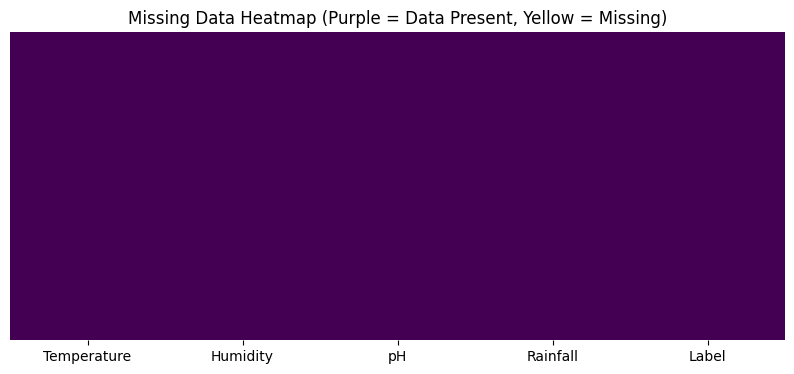

In [ ]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (Purple = Data Present, Yellow = Missing)')
plt.show()

In [ ]:
print("1. STRUCTURAL AUDIT")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\nColumn Data Types:")
print(df.dtypes)
print("-" * 30)

1. STRUCTURAL AUDIT
Total Rows: 7000
Total Columns: 5

Column Data Types:
Temperature    float64
Humidity       float64
pH             float64
Rainfall       float64
Label           object
dtype: object
------------------------------


In [ ]:
print(f"\nDuplicate Rows Found: {df.duplicated().sum()}")


Duplicate Rows Found: 0


In [ ]:
# 4. STATISTICAL AUDIT (Outliers & Range)
print("3. STATISTICAL AUDIT")
# Using .describe() to see min/max/mean/std
display(df.describe().T)
print("-" * 30)

3. STATISTICAL AUDIT


,count,mean,std,min,25%,50%,75%,max
Temperature,7000.0,23.493807,6.755644,6.105382,18.948438,23.344269,27.686253,46.791488
Humidity,7000.0,71.318934,22.289074,6.029440,58.055782,77.238068,90.259315,99.981876
pH,7000.0,6.454138,0.667650,3.504752,6.049754,6.406537,6.859321,9.935091
Rainfall,7000.0,751.476229,825.472175,20.211267,123.595859,644.904867,1051.049795,5989.995521


------------------------------


In [ ]:
# 4. STATISTICAL AUDIT (Outliers & Range)
print("3. STATISTICAL AUDIT")
# Using .describe() to see min/max/mean/std
display(df.describe())
print("-" * 30)

3. STATISTICAL AUDIT


,Temperature,Humidity,pH,Rainfall
count,7000.000000,7000.000000,7000.000000,7000.000000
mean,23.493807,71.318934,6.454138,751.476229
std,6.755644,22.289074,0.667650,825.472175
min,6.105382,6.029440,3.504752,20.211267
25%,18.948438,58.055782,6.049754,123.595859
50%,23.344269,77.238068,6.406537,644.904867
75%,27.686253,90.259315,6.859321,1051.049795
max,46.791488,99.981876,9.935091,5989.995521


------------------------------


In [ ]:
# 5. CLASS BALANCE (Is any crop over-represented?)
print("4. CLASS BALANCE")
print(df['Label'].value_counts())
print("-" * 30)

4. CLASS BALANCE
Label
Rice            100
Maize           100
Banana          100
Jute            100
Pulses          100
               ... 
Cashewnuts      100
French Beans    100
Sugarcane       100
Bajra           100
Mustard         100
Name: count, Length: 70, dtype: int64
------------------------------


VISUAL AUDIT

/tmp/ipykernel_19879/3035489537.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Label', palette='viridis', order=df['Label'].value_counts().index)


Text(0.5, 1.0, 'Crop Distribution (Class Balance)')

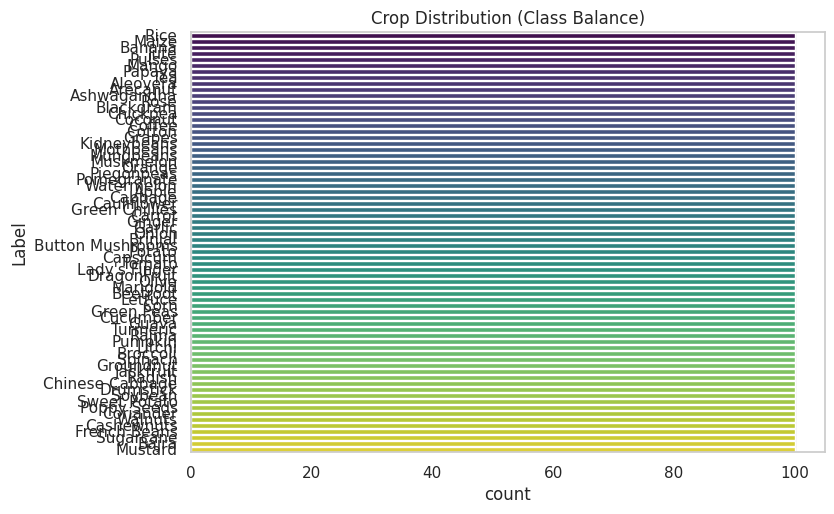

In [ ]:
# Set the style
sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))

# Subplot 1: Distribution of the Target (Label)
plt.subplot(2, 2, 1)
sns.countplot(data=df, y='Label', palette='viridis', order=df['Label'].value_counts().index)
plt.title('Crop Distribution (Class Balance)')

In [ ]:
The graph above is a **Countplot of Crop Distribution (Class Balance)**. Here's what it tells us:

*   **Type of Plot**: It's a bar chart that displays the frequency of each unique crop type (represented by the 'Label' column) in your dataset.
*   **Y-axis**: Shows the different crop labels (e.g., Rice, Maize, Banana, Jute), ordered by their frequency (though in this case, all have the same frequency).
*   **X-axis**: Shows the count or number of occurrences for each crop label.
*   **Interpretation**: From this graph, you can clearly see that **each crop type has an equal count of 100 entries**. This means your dataset is **perfectly balanced** in terms of class distribution. This is an excellent characteristic for a dataset, especially for machine learning tasks, as it helps prevent a model from being biased towards predicting more frequent classes and ensures it learns equally from all crop types.

SyntaxError: unterminated string literal (detected at line 1) (55615269.py, line 1)

Text(0.5, 1.0, 'Feature Correlation Heatmap')

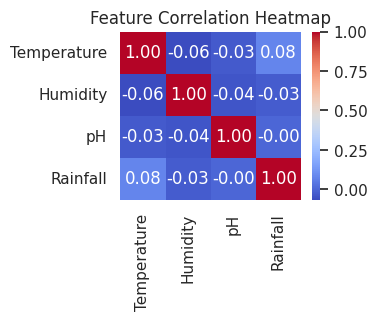

In [ ]:
import numpy as np

# Subplot 2: Correlation Heatmap (To see how features relate)
plt.subplot(2, 2, 2)
# Only correlate numeric columns
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')

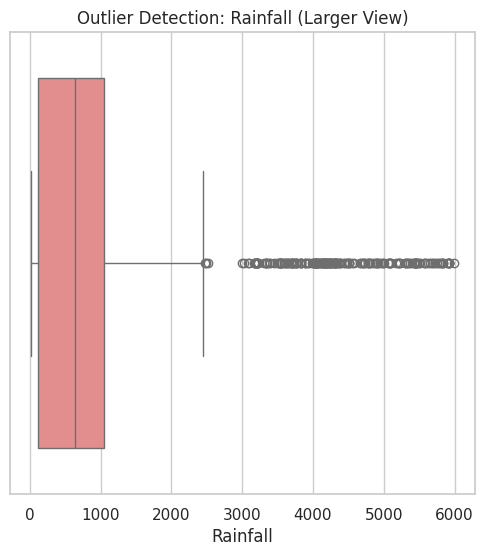

In [ ]:
plt.figure(figsize=(6, 6)) # Increased figure size
sns.boxplot(x=df['Rainfall'], color='lightcoral')
plt.title('Outlier Detection: Rainfall (Larger View)')
plt.xlabel('Rainfall')
plt.show()

DATA PREPROCESSING

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib # To save your 'brains' for the later app

# 1. Define Features (X) and Target (y)
X = df.drop('Label', axis=1)
y = df['Label']

# 2. Convert Crop Names to Numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Scale the features (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Save the 'Keys' (Encoder and Scaler)
# You will need these files later to build your end-to-end interface
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("✅ Preprocessing Complete!")
print(f"Total training samples: {X_train.shape[0]}")
print(f"Total testing samples: {X_test.shape[0]}")

✅ Preprocessing Complete!
Total training samples: 5600
Total testing samples: 1400


Step 3: Model Training (The "AI" Part)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model
model.fit(X_train_scaled, y_train)

# 3. Make Predictions on the test set
y_pred = model.predict(X_test_scaled)

# 4. Evaluate the Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"🏆 Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 5. Save the trained model
joblib.dump(model, 'crop_model.pkl')

🏆 Model Accuracy: 96.57%

Detailed Report:
                  precision    recall  f1-score   support

        Aleovera       1.00      1.00      1.00        12
           Apple       0.90      0.95      0.93        20
        Arecanut       1.00      0.93      0.97        15
     Ashwagandha       1.00      1.00      1.00        25
           Bajra       1.00      1.00      1.00        21
          Banana       1.00      1.00      1.00        22
        Beetroot       1.00      1.00      1.00        29
       Blackgram       0.88      1.00      0.94        15
         Brinjal       0.95      1.00      0.97        19
        Broccoli       1.00      1.00      1.00        18
Button Mushrooms       0.74      0.67      0.70        21
         Cabbage       0.94      1.00      0.97        15
        Capsicum       0.86      0.95      0.90        19
          Carrot       1.00      1.00      1.00        20
      Cashewnuts       1.00      0.87      0.93        23
     Cauliflower       1.00 

['crop_model.pkl']

Step 4: The Optimization Logic (The "What-If" Engine)

In [ ]:
import pandas as pd
import numpy as np

def suggest_crop(temp, humidity, ph, rainfall):
    # 1. Load the saved tools
    # (Assuming they are still in memory from the previous block)

    # 2. Prepare the input
    input_data = pd.DataFrame([[temp, humidity, ph, rainfall]],
                              columns=['Temperature', 'Humidity', 'pH', 'Rainfall'])

    # 3. Scale using the scaler we trained earlier
    input_scaled = scaler.transform(input_data)

    # 4. Predict
    prediction = model.predict(input_scaled)
    crop_name = le.inverse_transform(prediction)[0]

    return crop_name

# Example Test: Change these numbers to see different results!
my_crop = suggest_crop(temp=28, humidity=70, ph=6.5, rainfall=150)
print(f"🌱 Based on these conditions, the best crop to grow is: {my_crop}")

🌱 Based on these conditions, the best crop to grow is: Coffee


CONNECTING TO POWER BI

In [ ]:
import pandas as pd
import numpy as np

# Create a range of hypothetical scenarios
# Adjust these ranges based on your Data Audit (Min/Max)
temp_range = np.linspace(10, 40, 10)      # 10 values from 10 to 40 degrees
hum_range = np.linspace(20, 100, 10)     # 10 values from 20 to 100%
ph_range = np.linspace(4, 9, 5)          # 5 values from 4 to 9 pH
rain_range = np.linspace(20, 300, 10)    # 10 values from 20 to 300mm

# Create a meshgrid (all possible combinations)
mesh = np.array(np.meshgrid(temp_range, hum_range, ph_range, rain_range)).T.reshape(-1, 4)
hypothetical_df = pd.DataFrame(mesh, columns=['Temperature', 'Humidity', 'pH', 'Rainfall'])

# Use your trained scaler and model to predict for all these rows
hypothetical_scaled = scaler.transform(hypothetical_df)
predictions = model.predict(hypothetical_scaled)
hypothetical_df['Predicted_Crop'] = le.inverse_transform(predictions)

# Save for Power BI
hypothetical_df.to_csv('PowerBI_Crop_Predictions.csv', index=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


features = ['Temperature', 'Humidity', 'pH', 'Rainfall']
importances = model.feature_importances_

for f, s in zip(features, importances):
    print(f"{f}: {s:.4f}")

Temperature: 0.2000
Humidity: 0.3006
pH: 0.1692
Rainfall: 0.3302


In [ ]:
import joblib

# Replace these variable names with whatever you named your model/scaler in previous steps
joblib.dump(model, 'crop_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# Load the files we just saved
model = joblib.load('crop_model.pkl')
scaler = joblib.load('scaler.pkl')
le = joblib.load('label_encoder.pkl')

st.title("🌱 AI Crop Recommendation")
st.write("Adjust the environmental factors to see the AI's recommendation.")

# Layout with two columns
col1, col2 = st.columns(2)
with col1:
    temp = st.number_input("Temperature (°C)", value=25.0)
    hum = st.number_input("Humidity (%)", value=50.0)
with col2:
    ph = st.number_input("Soil pH", value=7.0)
    rain = st.number_input("Rainfall (mm)", value=100.0)

if st.button("Get Prediction"):
    # Reshape and Scale for the AI
    data = np.array([[temp, hum, ph, rain]])
    data_scaled = scaler.transform(data)

    # Predict and Show
    prediction = model.predict(data_scaled)
    crop = le.inverse_transform(prediction)[0]
    st.success(f"The best crop to plant is: **{crop}**")

main code to run

In [ ]:
# 1. Get your password/IP
print("COPY THIS IP ADDRESS:")
!wget -q -O - ipv4.icanhazip.com

# 2. Start the website
!pip install streamlit -q
!streamlit run app.py & npx localtunnel --port 8501

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501 --subdomain my-unique-project-123

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# --- 1. BACKGROUND IMAGE & UI CUSTOMIZATION ---
def add_bg_and_style():
    st.markdown(
        f"""
        <style>
        /* Sets the green scenery background */
        .stApp {{
            background-image: url("https://images.unsplash.com/photo-1500382017468-9049fed747ef?ixlib=rb-4.0.3&auto=format&fit=crop&w=1920&q=80");
            background-attachment: fixed;
            background-size: cover;
        }}

        /* Targets the main content container specifically to avoid extra top boxes */
        .stMainBlock {{
            background-color: rgba(255, 255, 255, 0.85);
            padding: 40px;
            border-radius: 15px;
            margin-top: 50px;
            margin-bottom: 50px;
            box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
        }}

        /* Optional: adjust the title color if needed */
        h1 {{
            color: #1E3D1E;
        }}
        </style>
        """,
        unsafe_allow_html=True
    )

add_bg_and_style()

# --- 2. LOAD TRAINED AI MODELS ---
# These files must be in your current working directory
model = joblib.load('crop_model.pkl')
scaler = joblib.load('scaler.pkl')
le = joblib.load('label_encoder.pkl')

# --- 3. STREAMLIT INTERFACE ---
st.title("🌱 AI Crop Recommendation")
st.write("Adjust the environmental factors to see the AI's recommendation.")

# Input fields in two columns
col1, col2 = st.columns(2)
with col1:
    temp = st.number_input("Temperature (°C)", value=25.0)
    hum = st.number_input("Humidity (%)", value=50.0)
with col2:
    ph = st.number_input("Soil pH", value=7.0)
    rain = st.number_input("Rainfall (mm)", value=100.0)

if st.button("Get Prediction"):
    # Reshape and Scale data for prediction
    data = np.array([[temp, hum, ph, rain]])
    data_scaled = scaler.transform(data)

    # Perform prediction
    prediction = model.predict(data_scaled)
    crop = le.inverse_transform(prediction)[0]

    # --- 4. HIGHLY VISIBLE OUTPUT BOX ---
    st.markdown(
        f"""
        <div style="
            background-color: #1E3D1E;
            padding: 25px;
            border-radius: 15px;
            border: 3px solid #4CAF50;
            text-align: center;
            margin-top: 25px;
            box-shadow: 0 10px 20px rgba(0,0,0,0.3);">
            <p style="color: #FFFFFF; font-size: 22px; margin-bottom: 10px; font-family: sans-serif;">
                The best crop to plant is:
            </p>
            <h1 style="color: #90EE90; font-size: 48px; margin: 0; font-weight: bold; font-family: serif;">
                {crop}
            </h1>
        </div>
        """,
        unsafe_allow_html=True
    )

Overwriting app.py


In [ ]:
# 1. Get your password/IP
print("COPY THIS IP ADDRESS:")
!wget -q -O - ipv4.icanhazip.com

# 2. Start the website
!pip install streamlit -q
!streamlit run app.py & npx localtunnel --port 8501

COPY THIS IP ADDRESS:
34.29.124.209
⠙

⠹⠸⠼⠴⠦your url is: https://four-actors-decide.loca.lt
2026-05-19 08:24:55.425 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.29.124.209:8501

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
